# Semana 3: Descenso del gradiente y condicionamiento

**Pregunta de trabajo.** Comprobar una actualización iterativa contra `lstsq` y medir cómo cambia la convergencia al escalar.

In [1]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler

In [2]:
X, y = make_regression(n_samples=120, n_features=2, noise=5, random_state=2105)
X = StandardScaler().fit_transform(X)
X = np.c_[np.ones(X.shape[0]), X]

In [3]:
def loss(X, y, theta):
    return np.mean((X @ theta - y) ** 2) / 2
def grad(X, y, theta):
    return X.T @ (X @ theta - y) / len(y)
theta = np.zeros(X.shape[1])
history = []
for _ in range(1000):
    history.append(loss(X, y, theta))
    theta -= 0.05 * grad(X, y, theta)
theta, history[-1]

(array([-1.99089343, 37.83125025, 78.18113922]), 13.861708987763135)

## Comprobaciones

La solución directa funciona como referencia. Después se modifica la escala manteniendo fija la regla de actualización.

In [4]:
theta_lstsq = np.linalg.lstsq(X, y, rcond=None)[0]
residual = y - X @ theta
comparison = {
    "norma_theta_gd_lstsq": float(np.linalg.norm(theta - theta_lstsq)),
    "ortogonalidad_residual": float(np.linalg.norm(X.T @ residual)),
    "norma_gradiente_final": float(np.linalg.norm(grad(X, y, theta))),
}
comparison

{'norma_theta_gd_lstsq': 1.465926642875835e-13,
 'ortogonalidad_residual': 1.8034892198845034e-11,
 'norma_gradiente_final': 1.502907683237086e-13}

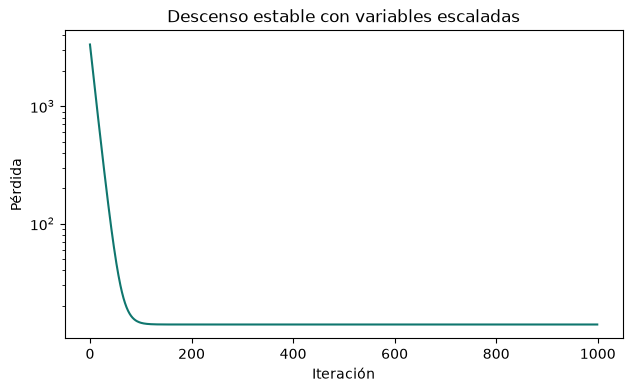

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.plot(history, color="#0f766e")
ax.set(xlabel="Iteración", ylabel="Pérdida", title="Descenso estable con variables escaladas")
ax.set_yscale("log")
plt.show()

In [6]:
alpha_rows = []
for alpha in [0.005, 0.05, 0.5, 1.5]:
    candidate = np.zeros(X.shape[1])
    values = []
    for _ in range(120):
        candidate -= alpha * grad(X, y, candidate)
        values.append(loss(X, y, candidate))
        if not np.isfinite(values[-1]):
            break
    alpha_rows.append((alpha, values[-1], np.isfinite(values[-1])))
alpha_rows

[(0.005, 1160.8241479080878, True),
 (0.05, 13.946087833526589, True),
 (0.5, 13.861708987763132, True),
 (1.5, 13.861708987763135, True)]

In [7]:
X_raw, y_raw = make_regression(n_samples=120, n_features=2, noise=5, random_state=2105)
X_bad = X_raw.copy()
X_bad[:, 1] *= 1_000_000
cond_before = np.linalg.cond(np.c_[np.ones(len(X_bad)), X_bad])
X_good = StandardScaler().fit_transform(X_bad)
cond_after = np.linalg.cond(np.c_[np.ones(len(X_good)), X_good])
{"cond_sin_escalar": cond_before, "cond_escalada": cond_after}

{'cond_sin_escalar': 1052404.8103231092, 'cond_escalada': 1.1619230402552136}

In [8]:
assert comparison["norma_theta_gd_lstsq"] < 1e-6
assert history[-1] < history[0]
print("Conclusión: el gradiente coincide con lstsq en el caso controlado; la tasa depende de la geometría de X.")

Conclusión: el gradiente coincide con lstsq en el caso controlado; la tasa depende de la geometría de X.
